In [8]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import cns
import cns.data_utils as cdu
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

C:\Users\adams\AppData\Local\Temp/ipykernel_13108/1427791538.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [ ]:
cns_dfs = {}
for grouping in ["10MB", "5MB", "3MB", "2MB", "1MB", "500KB", "250KB"]:
	samples_df, cns_df = cdu.main_load(grouping)
	cns_dfs[grouping] = cns_df
samples_df["type"].value_counts().head()

In [ ]:
cosmic = cdu.load_COSMIC()
ensembl = cdu.load_ENSEMBL()

In [ ]:
feature = "score"
val_count = 5

fig, axs = plt.subplots(len(cns_dfs), 1, figsize=(14, 14))

for i, (grouping, cns_df) in enumerate(cns_dfs.items()):

	lusc_df = cns.group_samples(cns.only_aut(cns.add_total_cn(cns_df)))
	lusc_df["sample_id"] = "mean LUSC CN"
	lusc_df["score"] = cns.calc_angles(lusc_df, "total_cn")

	cns.plot_lines(axs[i], lusc_df, cn_column="total_cn", color=color_map[i])
	cns.plot_x_lines(axs[i])
	cns.plot_x_ticks(axs[i])

	lusc_df = cns.add_cum_mid(lusc_df)
	lusc_df = lusc_df.sort_values(by="score")
	axs[i].scatter(lusc_df["cum_mid"].head(5), lusc_df["total_cn"].head(5), color="k", alpha=0.5, s=15, label="Top 5 peaks", marker="+")
	axs[i].scatter(lusc_df["cum_mid"].tail(5), lusc_df["total_cn"].tail(5), color="k", alpha=0.5, s=15, label="Top 5 valleys", marker="X")
	axs[i].set_ylim(0, 8)
	axs[i].set_ylabel("Total CN")
	axs[i].legend(title=f"{grouping} bins", loc="upper right", ncol=3)

axs[-1].set_xlabel("Poisition on linear genome")

cdu.save_cns_fig("peaks_valleys_all")

In [31]:
cosmic_means = []
ensembl_means = []

for i, (grouping, cns_df) in enumerate(cns_dfs.items()):
	print(grouping)
	lusc_df = cns.group_samples(cns.only_aut(cns.add_total_cn(cns_df)))
	lusc_df["sample_id"] = "mean LUSC CN"
	lusc_df["score"] = cns.calc_angles(lusc_df, "total_cn")
	
	cosmic_means.append(cns.mean_value_per_seg(lusc_df, cosmic, "score"))
	ensembl_means.append(cns.mean_value_per_seg(lusc_df, ensembl, "score"))

10MB
5MB
3MB
2MB
1MB
500KB
250KB


In [33]:
mean_dfs = {}
for name, means_list, target in zip(['cosmic', 'ensembl'], [cosmic_means, ensembl_means], [cosmic, ensembl]):
	mean_df = means_list[0].copy()
	for vals in means_list[1:]:
		mean_df["score"] += vals["score"]
	mean_df["score"] /= len(means_list)
	mean_df["total_cn"] = cns.mean_value_per_seg(lusc_df, target, "total_cn")["total_cn"]
	mean_dfs[name] = mean_df

both_means_df = mean_dfs['ensembl'].merge(
	mean_dfs['cosmic'][['chrom', 'start', 'end', 'name']],
	on=['chrom', 'start', 'end'],
	how='left',
	suffixes=('_ensembl', '_cosmic')
)

print(both_means_df[~both_means_df["name_cosmic"].isna()].sort_values(by="score", ascending=True).head(10))

both_means_df.to_csv(cdu.pjoin(cdu.out_path, "gene_scores_all.csv"), index=False)

       chrom      start        end     name_ensembl     score  total_cn  \
17294   chr7   55086713   55324313  ENSG00000146648 -0.423611  4.418679   
3691   chr11   69455854   69469242  ENSG00000110092 -0.374412  3.593908   
3698   chr11   70049268   70053496  ENSG00000168040 -0.352994  3.437112   
8252   chr17   37844166   37886679  ENSG00000141736 -0.349803  3.296131   
4824   chr12   69201955   69239214  ENSG00000135679 -0.344802  3.440343   
8255   chr17   37921197   38020441  ENSG00000161405 -0.309184  3.176233   
8245   chr17   37617763   37721160  ENSG00000167258 -0.201940  3.054013   
18498   chr8  128747679  128753674  ENSG00000136997 -0.189601  3.975192   
4771   chr12   58141509   58149796  ENSG00000135446 -0.173726  3.116789   
3870   chr11  102188214  102210134  ENSG00000023445 -0.143118  2.782654   

      name_cosmic  
17294        EGFR  
3691        CCND1  
3698         FADD  
8252        ERBB2  
4824         MDM2  
8255        IKZF3  
8245        CDK12  
18498         

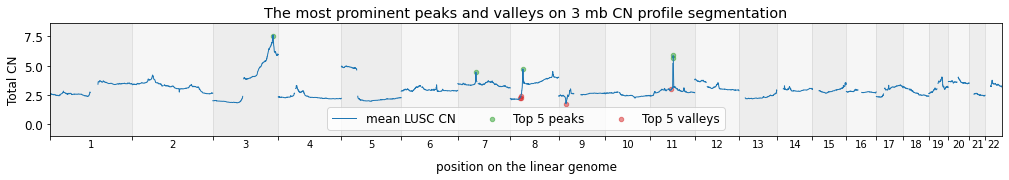

In [29]:
feature = "score"
val_count = 5
# indices of top 5 values

fig, ax = cns.fig_lines(lusc_df, cn_columns="total_cn", colors=color_map[0])
fig.set_size_inches(14, 2)

both_means_df = cns.add_cum_mid(both_means_df)
sel_df= both_means_df[~both_means_df["name_cosmic"].isna()].sort_values(by="score")
ax.scatter(sel_df["cum_mid"].head(5), sel_df["total_cn"].head(5), color=color_map[2], alpha=0.5, s=20, label="Top 5 peaks")
ax.scatter(sel_df["cum_mid"].tail(5), sel_df["total_cn"].tail(5), color=color_map[3], alpha=0.5, s=20, label="Top 5 valleys")

plt.title("The most prominent peaks and valleys on 3 mb CN profile segmentation")
plt.ylabel("Total CN")

# legend with 3 columns
ax.legend(loc="lower center", ncol=6)

cdu.save_cns_fig("3MB_cns_peaks_valleys")